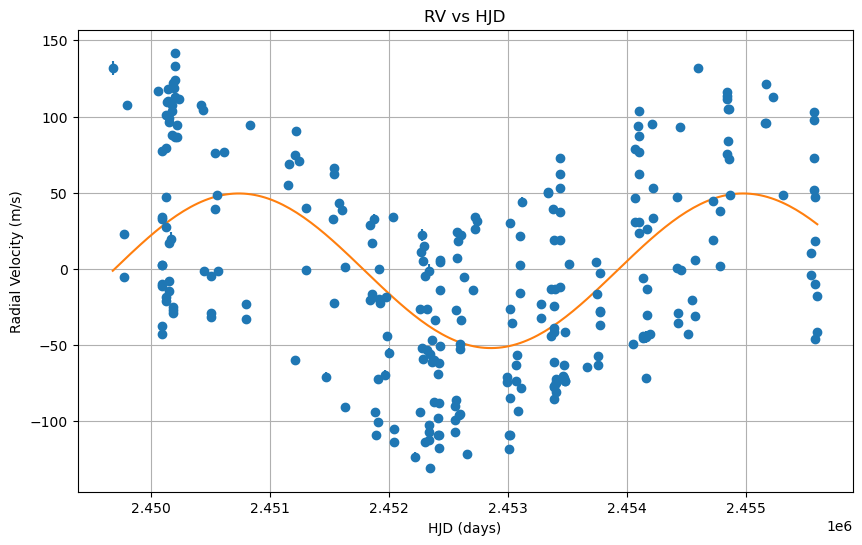

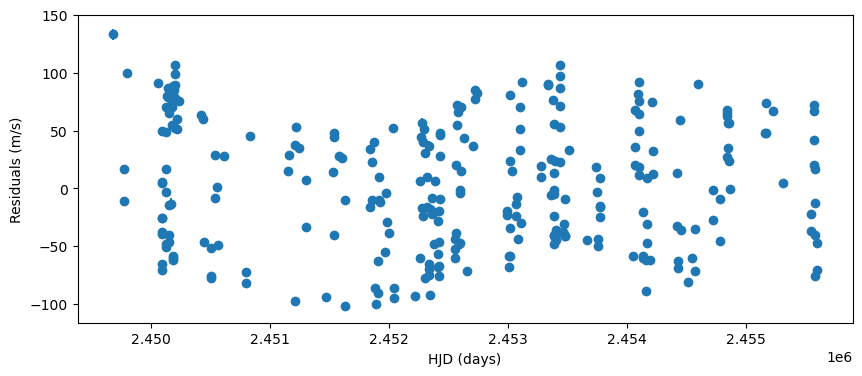

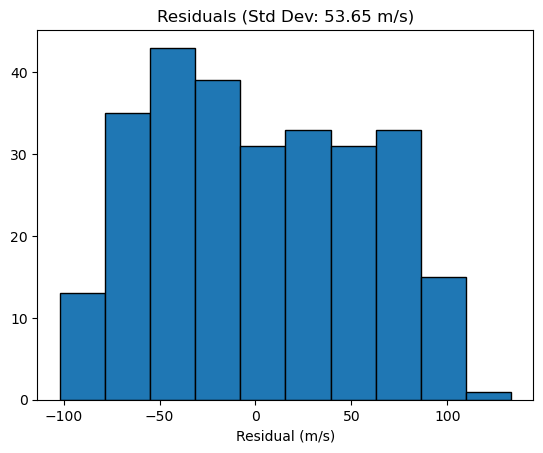

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# Siri Kancharla Final Project

data = np.loadtxt('data.astr19.txt')
time = data[:,0]
rv = data[:,1]
rv_error = data[:,2]
K=np.abs(data[:,1])


def rv_model(time, K, t0, P, v0):
    return K*np.sin(2*np.pi*(time - t0)/P) + v0


time_range = np.max(time) - np.min(time)
guess_P = time_range / 2  
guess_K = np.max(rv) - np.min(rv)
guess_t0 = np.min(time)
guess_v0 = np.mean(rv)  

guess_params = [guess_K/2, guess_t0, guess_P, guess_v0]


lower_bounds = [0, np.min(time), 0.1, -100]
upper_bounds = [100, np.max(time) + 1, time_range*2, 100]  


for i, (param, lower, upper) in enumerate(zip(guess_params, lower_bounds, upper_bounds)):
    if not (lower <= param <= upper):
        guess_params[i] = max(lower, min(param, upper))

best_params, _ = optimize.curve_fit(rv_model, time, rv, p0=guess_params,sigma=rv_error, maxfev=10000, bounds=(lower_bounds, upper_bounds))

best_K = best_params[0]
best_t0 = best_params[1]
best_P = best_params[2]
best_v0 = best_params[3]


time_fit = np.linspace(np.min(time), np.max(time), 200)
rv_fit = rv_model(time_fit, best_K, best_t0, best_P, best_v0)

plt.figure(figsize=(10, 6))
plt.errorbar(time, rv, yerr=rv_error, fmt='o')
plt.plot(time_fit, rv_fit)
plt.xlabel('HJD (days)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('RV vs HJD')
plt.grid(True)

residuals = rv - rv_model(time, best_K, best_t0, best_P, best_v0)
std_residuals = np.std(residuals)

plt.figure(figsize=(10, 4))
plt.errorbar(time, residuals, yerr=rv_error, fmt='o')
plt.xlabel('HJD (days)')
plt.ylabel('Residuals (m/s)')
plt.show()

plt.hist(residuals, bins=10, edgecolor='black')
plt.title(f'Residuals (Std Dev: {std_residuals:.2f} m/s)')
plt.xlabel('Residual (m/s)')
plt.show()